In [2]:
import pandas as pd
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error
from lightgbm import LGBMRegressor
from statsmodels.stats.outliers_influence import variance_inflation_factor

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [3]:
# bdi=pd.read_csv('../data/Baltic Dry Index Historical Data/Baltic Dry Index Historical Data_14.01~14.08.csv')
# bdi['Date']=pd.to_datetime(bdi['Date'])
# bdi.drop(columns=['Vol.'],inplace=True)
# bdi.tail()

In [4]:
# df = pd.read_csv("data.csv")
# df["Date"] = pd.to_datetime(df["Date"])
# # 3. 콤마/퍼센트 제거 후 숫자로 변환
# num_cols = ["Price", "Open", "High", "Low"]
# for col in num_cols:
#     bdi[col] = (
#         bdi[col]
#         .astype(str)
#         .str.replace(",", "", regex=False)
#         .astype(float)
#     )

# bdi["Change %"] = (
#     bdi["Change %"]
#     .astype(str)
#     .str.replace("%", "", regex=False)
#     .astype(float) / 100.0   # -2.67% → -0.0267
# )

# # 4. 컬럼명 통일 (기존 피처 이름에 맞추기)
# bdi = bdi.rename(columns={
#     "Price": "bdi_price",
#     "Open": "bdi_open",
#     "High": "bdi_high",
#     "Low": "bdi_low",
#     "Change %": "bdi_change_%"
# })

# # 여기서 bdi에는 [Date, bdi_price, bdi_open, bdi_high, bdi_low, bdi_change_%]

# # =========================
# # 아래는 기존 마스터 DF에 붙이는 부분
# # 기존 df 이름이 merged 라고 가정 (질문에 있는 두 번째 표)

# # 5. Date 기준으로 merge
# merged = df.merge(bdi, on="Date", how="left", suffixes=("", "_new"))

# # 6. 이미 bdi_* 컬럼이 있고 NaN만 채우고 싶다면:
# cols = ["bdi_price", "bdi_open", "bdi_high", "bdi_low", "bdi_change_%"]

# for c in cols:
#     new_col = f"{c}_new"
#     if new_col in merged.columns:
#         # 기존 값이 NaN인 곳만 새 값으로 채움
#         merged[c] = merged[c].combine_first(merged[new_col])
#         merged.drop(columns=[new_col], inplace=True)

# merged.head()

In [5]:
df = pd.read_csv("data.csv")

# 날짜 처리 + 정렬
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").drop_duplicates("Date").reset_index(drop=True)

# 퍼센트 문자열 컬럼 안전 변환 (예: '1.2%' -> 0.012)
pct_cols = [c for c in df.columns if "change_%" in c or c.endswith("%")]
for c in pct_cols:
    df[c] = (df[c].astype(str).str.replace("%", "", regex=False).str.replace(",", "", regex=False))
    df[c] = pd.to_numeric(df[c], errors="coerce") / 100.0

# 숫자형 안전 변환 (쉼표 제거)
for c in df.columns:
    if c == "Date": 
        continue
    if df[c].dtype == "object":
        df[c] = df[c].astype(str).str.replace(",", "", regex=False)
        df[c] = pd.to_numeric(df[c], errors="coerce")

In [6]:
print("행/열:", df.shape)
display(df.head(3))
display(df.tail(3))

# 타입 요약
display(df.dtypes.to_frame("dtype"))

# 결측 요약
na = df.isna().mean().sort_values(ascending=False)
display(na.to_frame("na_ratio").head(20))


행/열: (2985, 50)


,Date,brent_close,wti_close,brent_wti_spread,brent_ret_1d,brent_ret_5d,brent_ret_20d,brent_ma_5,brent_ma_20,brent_ma_60,brent_vol_5d,high_low_range,crude_stock_level,gas_stock_level,dist_stock_level,crude_stock_wow_change,gas_stock_wow_change,dist_stock_wow_change,crude_stock_vs_5yr_avg,gas_stock_vs_5yr_avg,dist_stock_vs_5yr_avg,prod_weekly,prod_4w_ma,prod_wow_change,crude_exports,crude_imports,import_4w_ma,net_imports,refinery_run_rate,wti_mm_net_long,wti_mm_net_long_ratio,wti_producer_hedge_ratio,wti_mm_position_change_wow,wti_sentiment_position,DXY_DX-Y.NYB,XLE_XLE,VDE_VDE,IXC_IXC,"('DXY', 'DX-Y.NYB')_ret_1d","('XLE', 'XLE')_ret_1d","('VDE', 'VDE')_ret_1d","('IXC', 'IXC')_ret_1d",us10y_yield,us2y_yield,term_spread,bdi_price,bdi_open,bdi_high,bdi_low,bdi_change_%
0,2014-01-02,107.779999,95.440002,12.339996,-0.027256,-0.036819,-0.032930,110.790001,110.6705,109.391334,0.011831,0.033680,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,80.629997,55.728355,85.919937,27.177940,NaN,NaN,NaN,NaN,3.00,0.39,2.61,2113.0,2113.0,2113.0,2113.0,-0.0720
1,2014-01-03,106.889999,93.959999,12.930000,-0.008258,-0.045455,-0.050879,109.772000,110.3840,109.356167,0.010935,0.017214,326737.0,226959.0,226959.0,-3958.0,6243.0,6243.0,-0.025439,0.048841,0.048841,8145.0,8108.75,0.002955,58.0,7961.0,7680.75,7903.0,92.3,NaN,NaN,NaN,NaN,NaN,80.790001,55.523968,85.713120,27.133375,0.001984,-0.003668,-0.002407,-0.001640,3.01,0.41,2.60,2036.0,2036.0,2036.0,2036.0,-0.0364
2,2014-01-06,106.730003,93.430000,13.300003,-0.001497,-0.048583,-0.046031,108.682001,110.1265,109.310667,0.010182,0.012836,326737.0,226959.0,226959.0,-3958.0,6243.0,6243.0,-0.025439,0.048841,0.048841,8145.0,8108.75,0.002955,58.0,7961.0,7680.75,7903.0,92.3,NaN,NaN,NaN,NaN,NaN,80.650002,55.600628,85.692451,27.031513,-0.001733,0.001381,-0.000241,-0.003754,2.98,0.40,2.58,1951.0,1951.0,1951.0,1951.0,-0.0417


,Date,brent_close,wti_close,brent_wti_spread,brent_ret_1d,brent_ret_5d,brent_ret_20d,brent_ma_5,brent_ma_20,brent_ma_60,brent_vol_5d,high_low_range,crude_stock_level,gas_stock_level,dist_stock_level,crude_stock_wow_change,gas_stock_wow_change,dist_stock_wow_change,crude_stock_vs_5yr_avg,gas_stock_vs_5yr_avg,dist_stock_vs_5yr_avg,prod_weekly,prod_4w_ma,prod_wow_change,crude_exports,crude_imports,import_4w_ma,net_imports,refinery_run_rate,wti_mm_net_long,wti_mm_net_long_ratio,wti_producer_hedge_ratio,wti_mm_position_change_wow,wti_sentiment_position,DXY_DX-Y.NYB,XLE_XLE,VDE_VDE,IXC_IXC,"('DXY', 'DX-Y.NYB')_ret_1d","('XLE', 'XLE')_ret_1d","('VDE', 'VDE')_ret_1d","('IXC', 'IXC')_ret_1d",us10y_yield,us2y_yield,term_spread,bdi_price,bdi_open,bdi_high,bdi_low,bdi_change_%
2982,2025-11-12,62.709999,58.490002,4.219997,-0.037600,-0.012752,0.012922,63.788,63.8000,65.738333,0.020894,0.042258,427581.0,205064.0,205064.0,6413.0,-945.0,-945.0,-0.027498,-0.099603,-0.099603,13862.0,13696.5,0.015457,2816.0,5222.0,5528.75,2406.0,89.4,NaN,NaN,NaN,NaN,NaN,99.480003,90.250000,127.190002,42.959999,0.000201,-0.013984,-0.014031,-0.010138,4.08,3.56,0.52,NaN,NaN,NaN,NaN,NaN
2983,2025-11-13,63.009998,58.689999,4.320000,0.004784,-0.005838,0.031936,63.714,63.8975,65.674500,0.021141,0.017458,427581.0,205064.0,205064.0,6413.0,-945.0,-945.0,-0.027498,-0.099603,-0.099603,13862.0,13696.5,0.015457,2816.0,5222.0,5528.75,2406.0,89.4,NaN,NaN,NaN,NaN,NaN,99.180000,90.480003,127.279999,42.959999,-0.003016,0.002549,0.000708,0.000000,4.11,3.58,0.53,NaN,NaN,NaN,NaN,NaN
2984,2025-11-14,64.389999,60.090000,4.299999,0.021901,0.011944,0.050579,63.866,64.0525,65.619833,0.023574,0.027955,427581.0,205064.0,205064.0,6413.0,-945.0,-945.0,-0.027498,-0.099603,-0.099603,13862.0,13696.5,0.015457,2816.0,5222.0,5528.75,2406.0,89.4,NaN,NaN,NaN,NaN,NaN,99.269997,92.019997,129.339996,43.560001,0.000907,0.017020,0.016185,0.013967,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,dtype
Date,datetime64[ns]
brent_close,float64
wti_close,float64
brent_wti_spread,float64
brent_ret_1d,float64
brent_ret_5d,float64
brent_ret_20d,float64
brent_ma_5,float64
brent_ma_20,float64
brent_ma_60,float64


,na_ratio
wti_producer_hedge_ratio,0.795645
wti_mm_net_long_ratio,0.795645
wti_sentiment_position,0.795645
wti_mm_position_change_wow,0.795645
wti_mm_net_long,0.795645
bdi_low,0.032496
bdi_open,0.032496
bdi_high,0.032496
bdi_price,0.032496
bdi_change_%,0.032496


cftc na값 왜케 많음??

일일 예측 모델에서 주간 변수 영향이 반영되어야함.

근데 비갱신일에 정보 누수도 없어야 돼서 가짜 상관도 없어야함

- 커버리지 확인(20퍼): 영업일 때문일거임. 긍까 그냥 발표일말고 비워져있는 것
- 날짜도 봣는데 발표일(화요일)말고 거의 비워져잇음
- 변화량/충격 얘네를 비갱신일에 채워야 하는가?
    1. 진짜 주단위로 보간 (선형엔 필요함)
    2. 트리계열 쓸거면 상관없는거 같음

*일단은 이렇게 만들어 볼게요*

shock_raw: 이번 주 포지션 변화량 (시장 심리의 ‘충격’ 크기)

shock_decay: 발표 후 영향이 점점 줄어드는 일간 신호

days_since_update: 얼마나 오래된 정보인지(0=화요일, 3=금요일…)

avail: 이 주간 신호가 “아직 유효한 구간”인지 여부

In [7]:
cftc_cols = [
    "wti_mm_net_long","wti_mm_net_long_ratio",
    "wti_producer_hedge_ratio","wti_mm_position_change_wow",
    "wti_sentiment_position"
]
for c in cftc_cols:
    if c in df.columns:
        s = df[["Date", c]].dropna()
        print(c, "coverage:", 1 - df[c].isna().mean())
        print(c, "first_valid:", s["Date"].min() if len(s) else None)


# 커버리지가 지금 20퍼니까 아마 영업일때문일거야

wti_mm_net_long coverage: 0.2043551088777219
wti_mm_net_long first_valid: 2014-01-07 00:00:00
wti_mm_net_long_ratio coverage: 0.2043551088777219
wti_mm_net_long_ratio first_valid: 2014-01-07 00:00:00
wti_producer_hedge_ratio coverage: 0.2043551088777219
wti_producer_hedge_ratio first_valid: 2014-01-07 00:00:00
wti_mm_position_change_wow coverage: 0.2043551088777219
wti_mm_position_change_wow first_valid: 2014-01-07 00:00:00
wti_sentiment_position coverage: 0.2043551088777219
wti_sentiment_position first_valid: 2014-01-07 00:00:00


In [8]:
# 비결측일의 요일 분포 확인 (월=0, 화=1, ... 일=6)
for c in ["wti_mm_net_long","wti_mm_net_long_ratio","wti_producer_hedge_ratio",
          "wti_mm_position_change_wow","wti_sentiment_position"]:
    if c in df.columns:
        nonnull = df.loc[~df[c].isna(), ["Date", c]].copy()
        nonnull["weekday"] = nonnull["Date"].dt.weekday
        print(c, nonnull["weekday"].value_counts().sort_index())


wti_mm_net_long

 weekday
0      5
1    605
Name: count, dtype: int64
wti_mm_net_long_ratio weekday
0      5
1    605
Name: count, dtype: int64
wti_producer_hedge_ratio weekday
0      5
1    605
Name: count, dtype: int64
wti_mm_position_change_wow weekday
0      5
1    605
Name: count, dtype: int64
wti_sentiment_position weekday
0      5
1    605
Name: count, dtype: int64


### CFTC shock 신호와 Brent 수익률 간 시차 상관
- wti_mm_net_long_shock_decay : 음 ~>양 발표직후 아마 이익실현? 그리고 그 주 후반에 다시 상승 모멘텀
- wti_mm_net_long_ratio_shock_decay: 거의 동일함. 과열기에 단기 조정 그리고 회복 -- 얜 심리주기 반영
- wti_producer_hedge_ratio_shock_decay: 일관된 +. 생산자가 헷지 늘릴수록 시장은 고점 신호로 보는거임
- wti_mm_position_change_wow_shock_decay: 초반 음 ~>양. 급격한 매수 전환 후엔 단기 조정
- wti_sentiment_position_shock_decay: 계속 음. 모르게ㅆ으ㅁ

In [9]:
def weekly_signal_to_daily_series(df, col, update_weekday=1, max_carry_days=7, half_life_days=3):
    """
    df: Date 컬럼 포함, 정렬 가정
    col: 주간으로 갱신되는 원천 컬럼명
    반환: shock_decay (Series, index=df.index)  // df에 아무것도 추가 안 함
    """
    idx = df.index
    weekday = df["Date"].dt.weekday
    x = df[col]

    # 1) '업데이트일' 마스크 (예: 화요일 & 값 존재)
    is_upd = (weekday == update_weekday) & x.notna()

    # 2) 업데이트일 값들만 뽑아서 업데이트 간 차분(shock)
    upd_series = x[is_upd]
    shock_on_updates = upd_series.diff()  # 지난 업데이트 대비 변화(week-over-week)

    # 3) 전체 인덱스에 shock 배치 (그 외 NaN)
    shock_raw = pd.Series(np.nan, index=idx)
    shock_raw.loc[shock_on_updates.index] = shock_on_updates.values

    # 4) 그룹 ID: 업데이트가 발생할 때마다 증가
    grp = is_upd.cumsum()

    # 5) 발표 후 경과일(0,1,2,...) — 첫 업데이트 전 구간은 NaN
    days_since = df.groupby(grp).cumcount()
    days_since = days_since.where(grp > 0, np.nan)
    days_since = days_since.where(days_since <= max_carry_days, np.nan)

    # 6) shock 브로드캐스트: 직전 업데이트 shock를 carry
    shock_broadcast = shock_raw.ffill()
    shock_broadcast = shock_broadcast.where(days_since.notna(), np.nan)  # carry 제한

    # 7) 감쇠(half-life)
    decay = np.where(days_since.notna(), 0.5 ** (days_since.astype(float) / half_life_days), 0.0)
    shock_decay = shock_broadcast * decay

    return shock_decay  # <- df에 컬럼 추가 안 함 (임시 시리즈)

def lag_corr(x, y, max_lag=7):
    out = {}
    for k in range(max_lag + 1):
        s = pd.concat([y.rename("y"), x.shift(k).rename("x")], axis=1).dropna()
        out[k] = s["y"].corr(s["x"]) if len(s) else np.nan
    return pd.Series(out)

# 타깃: 일간 로그수익률
y = np.log(df["brent_close"]).diff()

cftc_cols = [
    "wti_mm_net_long","wti_mm_net_long_ratio",
    "wti_producer_hedge_ratio","wti_mm_position_change_wow",
    "wti_sentiment_position"
]

for col in cftc_cols:
    if col in df.columns:
        sig = weekly_signal_to_daily_series(
            df, col,
            update_weekday=1,     # 화요일
            max_carry_days=7,     # carry 제한
            half_life_days=3      # 감쇠 반감기
        )
        print(f"\n{col} (shock_decay)")
        print(lag_corr(sig, y, max_lag=7))



wti_mm_net_long (shock_decay)
0   -0.015118
1   -0.018568
2   -0.013782
3   -0.002579
4    0.001776
5    0.006302
6    0.012679
7    0.000417
dtype: float64

wti_mm_net_long_ratio (shock_decay)
0   -0.004119
1   -0.007221
2   -0.007370
3    0.000373
4    0.000307
5    0.003884
6    0.011586
7    0.001901
dtype: float64

wti_producer_hedge_ratio (shock_decay)
0    0.035064
1    0.039275
2    0.046634
3    0.026557
4    0.001980
5    0.003475
6   -0.001252
7    0.014433
dtype: float64

wti_mm_position_change_wow (shock_decay)
0   -0.011734
1   -0.015960
2   -0.009156
3    0.003779
4   -0.001671
5    0.008851
6    0.010128
7   -0.006649
dtype: float64

wti_sentiment_position (shock_decay)
0   -0.006186
1   -0.007452
2   -0.012327
3   -0.008250
4   -0.005496
5   -0.003829
6    0.004554
7   -0.014403
dtype: float64


In [10]:

def add_cftc_features(
    df: pd.DataFrame,
    cols,
    update_weekday: int = 1,      # 0=월, 1=화, ...
    max_carry_days: int = 7,      # 발표 후 최대 며칠까지 효과 인정할지
    half_life_days: float = 3.0   # shock_decay 반감기
) -> pd.DataFrame:


    df = df.sort_values("Date").reset_index(drop=True).copy()

    if "Date" not in df.columns:
        raise ValueError("Date 컬럼이 필요합니다.")
    df["Date"] = pd.to_datetime(df["Date"])
    weekday = df["Date"].dt.weekday

    for col in cols:
        if col not in df.columns:
            continue

        # 1) 실제 업데이트일: 화요일 & 값 존재
        is_update = (weekday == update_weekday) & df[col].notna()
        df[f"{col}_is_update"] = is_update.astype(int)

        # 업데이트일 값들만 뽑아서 '업데이트 간 차분'으로 shock 계산
        upd_vals = df.loc[is_update, col]
        # 첫 업데이트는 이전 값이 없으니 NaN, 이후부터 week-over-week 변화
        upd_shock = upd_vals.diff()

        # 전체 일자 인덱스에 shock_raw 맵핑 (업데이트일만 값, 나머지 NaN)
        shock_raw = pd.Series(np.nan, index=df.index)
        shock_raw.loc[upd_shock.index] = upd_shock.values
        df[f"{col}_shock_raw"] = shock_raw

        # 2) 그룹 ID: 업데이트가 나올 때마다 +1
        grp_id = is_update.cumsum()

        # 3) days_since_update: 각 그룹 내에서 0,1,2,... 카운트
        #    첫 업데이트 이전(grp_id==0)은 NaN
        days_since = df.groupby(grp_id).cumcount()
        days_since = days_since.where(grp_id > 0, np.nan)
        # max_carry_days 넘으면 효과 없음 → NaN 처리
        days_since = days_since.where(days_since <= max_carry_days, np.nan)
        df[f"{col}_days_since_update"] = days_since

        # 4) shock_broadcast: 직전 업데이트 shock를 carry, carry 가능한 날만
        shock_broadcast = df[f"{col}_shock_raw"].ffill()
        shock_broadcast = shock_broadcast.where(days_since.notna(), np.nan)

        # 5) avail: 이 날이 해당 shock의 유효 구간인지 (carry 중인지)
        avail = shock_broadcast.notna().astype(int)
        df[f"{col}_avail"] = avail

        # 6) shock_decay: shock_broadcast * decay(days_since)
        decay = np.where(
            days_since.notna(),
            0.5 ** (days_since.astype(float) / float(half_life_days)),
            0.0
        )
        df[f"{col}_shock_decay"] = shock_broadcast * decay

    return df


In [11]:
cftc_cols = [
    "wti_mm_net_long",
    "wti_mm_net_long_ratio",
    "wti_producer_hedge_ratio",
    "wti_mm_position_change_wow",
    "wti_sentiment_position",
]

df = add_cftc_features(df, cftc_cols, update_weekday=1, max_carry_days=7, half_life_days=3)
df.head(7)

,Date,brent_close,wti_close,brent_wti_spread,brent_ret_1d,brent_ret_5d,brent_ret_20d,brent_ma_5,brent_ma_20,brent_ma_60,brent_vol_5d,high_low_range,crude_stock_level,gas_stock_level,dist_stock_level,crude_stock_wow_change,gas_stock_wow_change,dist_stock_wow_change,crude_stock_vs_5yr_avg,gas_stock_vs_5yr_avg,dist_stock_vs_5yr_avg,prod_weekly,prod_4w_ma,prod_wow_change,crude_exports,crude_imports,import_4w_ma,net_imports,refinery_run_rate,wti_mm_net_long,wti_mm_net_long_ratio,wti_producer_hedge_ratio,wti_mm_position_change_wow,wti_sentiment_position,DXY_DX-Y.NYB,XLE_XLE,VDE_VDE,IXC_IXC,"('DXY', 'DX-Y.NYB')_ret_1d","('XLE', 'XLE')_ret_1d","('VDE', 'VDE')_ret_1d","('IXC', 'IXC')_ret_1d",us10y_yield,us2y_yield,term_spread,bdi_price,bdi_open,bdi_high,bdi_low,bdi_change_%,wti_mm_net_long_is_update,wti_mm_net_long_shock_raw,wti_mm_net_long_days_since_update,wti_mm_net_long_avail,wti_mm_net_long_shock_decay,wti_mm_net_long_ratio_is_update,wti_mm_net_long_ratio_shock_raw,wti_mm_net_long_ratio_days_since_update,wti_mm_net_long_ratio_avail,wti_mm_net_long_ratio_shock_decay,wti_producer_hedge_ratio_is_update,wti_producer_hedge_ratio_shock_raw,wti_producer_hedge_ratio_days_since_update,wti_producer_hedge_ratio_avail,wti_producer_hedge_ratio_shock_decay,wti_mm_position_change_wow_is_update,wti_mm_position_change_wow_shock_raw,wti_mm_position_change_wow_days_since_update,wti_mm_position_change_wow_avail,wti_mm_position_change_wow_shock_decay,wti_sentiment_position_is_update,wti_sentiment_position_shock_raw,wti_sentiment_position_days_since_update,wti_sentiment_position_avail,wti_sentiment_position_shock_decay
0,2014-01-02,107.779999,95.440002,12.339996,-0.027256,-0.036819,-0.032930,110.790001,110.6705,109.391334,0.011831,0.033680,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,80.629997,55.728355,85.919937,27.177940,NaN,NaN,NaN,NaN,3.00,0.39,2.61,2113.0,2113.0,2113.0,2113.0,-0.0720,0,NaN,NaN,0,NaN,0,NaN,NaN,0,NaN,0,NaN,NaN,0,NaN,0,NaN,NaN,0,NaN,0,NaN,NaN,0,NaN
1,2014-01-03,106.889999,93.959999,12.930000,-0.008258,-0.045455,-0.050879,109.772000,110.3840,109.356167,0.010935,0.017214,326737.0,226959.0,226959.0,-3958.0,6243.0,6243.0,-0.025439,0.048841,0.048841,8145.0,8108.75,0.002955,58.0,7961.0,7680.75,7903.0,92.3,NaN,NaN,NaN,NaN,NaN,80.790001,55.523968,85.713120,27.133375,0.001984,-0.003668,-0.002407,-0.001640,3.01,0.41,2.60,2036.0,2036.0,2036.0,2036.0,-0.0364,0,NaN,NaN,0,NaN,0,NaN,NaN,0,NaN,0,NaN,NaN,0,NaN,0,NaN,NaN,0,NaN,0,NaN,NaN,0,NaN
2,2014-01-06,106.730003,93.430000,13.300003,-0.001497,-0.048583,-0.046031,108.682001,110.1265,109.310667,0.010182,0.012836,326737.0,226959.0,226959.0,-3958.0,6243.0,6243.0,-0.025439,0.048841,0.048841,8145.0,8108.75,0.002955,58.0,7961.0,7680.75,7903.0,92.3,NaN,NaN,NaN,NaN,NaN,80.650002,55.600628,85.692451,27.031513,-0.001733,0.001381,-0.000241,-0.003754,2.98,0.40,2.58,1951.0,1951.0,1951.0,1951.0,-0.0417,0,NaN,NaN,0,NaN,0,NaN,NaN,0,NaN,0,NaN,NaN,0,NaN,0,NaN,NaN,0,NaN,0,NaN,NaN,0,NaN
3,2014-01-07,107.349998,93.669998,13.680000,0.005809,-0.034709,-0.032709,107.910001,109.9450,109.271834,0.012422,0.007452,326737.0,226959.0,226959.0,-3958.0,6243.0,6243.0,-0.025439,0.048841,0.048841,8145.0,8108.75,0.002955,58.0,7961.0,7680.75,7903.0,92.3,50512.0,0.09363,0.252797,-5451.0,1.0,80.830002,56.022179,86.361214,27.241602,0.002232,0.007582,0.007804,0.007772,2.96,0.40,2.56,1876.0,1876.0,1876.0,1876.0,-0.0384,1,NaN,0.0,0,NaN,1,NaN,0.0,0,NaN,1,NaN,0.0,0,NaN,1,NaN,0.0,0,NaN,1,NaN,0.0,0,NaN
4,2014-01-08,107.150002,92.330002,14.820000,-0.001863,-0.032942,-0.039961,107.180000,109.7220,109.221667,0.012569,0.008493,326737.0,226959.0,226959.0,-3958.0,6243.0,6243.0,-0.025439,0.048841,0.048841,8145.0,8108.75,0.002955,58.0,7961.0,7680.75,7903.0,92.3,NaN,NaN,NaN,NaN,NaN,81.040001,55.632557,85.802750,27.095177,0.002598,-0.006955,-0.006467,-0.005375,3.01,0.43,2.58,1826.0,1826.0,1826.0,1826.0,-0.0267,0,NaN,1.0,0,NaN,0,NaN,1.0,0,NaN,0,NaN,1.0,0,NaN,0,NaN,1.0,0,NaN,0,NaN,1.0,0,NaN
5,2014-01-09,106.389999,

In [12]:
"""
트리 계열 모델:

*_shock_decay, *_is_update, *_avail 위주로 넣으면 충분합니다.

신경망/선형:

*_shock_decay NaN은 0으로 채워 사용해도 됩니다.
"""

'\n트리 계열 모델:\n\n*_shock_decay, *_is_update, *_avail 위주로 넣으면 충분합니다.\n\n신경망/선형:\n\n*_shock_decay NaN은 0으로 채워 사용해도 됩니다.\n'

In [13]:
# # 완전 상수 컬럼
# nunique = df.nunique().sort_values()
# display(nunique.head(10))

# 중복 칼럼명 제거(있다면)
df = df.loc[:, ~df.columns.duplicated()]

# 간단 이상치 후보 (표준화 기준 |z|>4)
# ㅇㅒ네가 결국에 이벤트가 될거같음
num_cols = [c for c in df.columns if c != "Date" and pd.api.types.is_numeric_dtype(df[c])]
z = (df[num_cols] - df[num_cols].mean())/df[num_cols].std(ddof=0)
outlier_counts = (z.abs() > 4).sum().sort_values(ascending=False)
display(outlier_counts.head(15))


wti_sentiment_position_shock_decay    63
prod_wow_change                       53
wti_producer_hedge_ratio_avail        47
wti_mm_net_long_ratio_avail           47
wti_sentiment_position_avail          47
wti_mm_net_long_avail                 47
wti_mm_position_change_wow_avail      47
brent_vol_5d                          30
brent_ret_5d                          23
brent_ret_20d                         23
bdi_price                             22
bdi_open                              22
bdi_high                              22
bdi_low                               22
high_low_range                        22
dtype: int64

In [14]:
# 대표 주간지표 몇 개 골라 forward fill 의존도 확인
# 근데 나는 이거 적용일(?) 기준으로 그냥 최대 7일씩만 채웠는데 이건 내 잘못이 아니고 그냥 진짜 이렇게 생긴거잖아
weekly_like = [
    "crude_stock_level","crude_stock_wow_change","crude_stock_vs_5yr_avg",
    "gas_stock_level","dist_stock_level",
    "prod_weekly","prod_4w_ma","prod_wow_change",
    "crude_imports","crude_exports","import_4w_ma","net_imports",
    "refinery_run_rate",
    "wti_mm_net_long","wti_mm_net_long_ratio","wti_producer_hedge_ratio","wti_mm_position_change_wow",
    "wti_sentiment_position"
]
present_weekly = [c for c in weekly_like if c in df.columns]

# 동일값 연속 길이(=주간 한 번 발표 후 FFill된 길이) 분포 확인
from itertools import groupby
for c in present_weekly[:8]:
    streaks = [sum(1 for _ in g) for k, g in groupby(df[c].fillna(-9999).values)]
    print(c, "최빈 연속길이(상위 3):", pd.Series(streaks).value_counts().head(3).to_dict())

crude_stock_level 최빈 연속길이(상위 3): {5: 489, 4: 87, 9: 17}
crude_stock_wow_change 최빈 연속길이(상위 3): {5: 489, 4: 87, 9: 17}
crude_stock_vs_5yr_avg 최빈 연속길이(상위 3): {5: 489, 4: 87, 9: 17}
gas_stock_level 최빈 연속길이(상위 3): {5: 489, 4: 87, 9: 17}
dist_stock_level 최빈 연속길이(상위 3): {5: 489, 4: 87, 9: 17}
prod_weekly 최빈 연속길이(상위 3): {5: 306, 4: 54, 10: 40}
prod_4w_ma 최빈 연속길이(상위 3): {5: 378, 4: 66, 9: 24}
prod_wow_change 최빈 연속길이(상위 3): {5: 418, 4: 64, 9: 20}


c:\Users\SKAX\Desktop\project\Market-Plan-B-AI\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54645 (\N{HANGUL SYLLABLE HAEG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\SKAX\Desktop\project\Market-Plan-B-AI\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49900 (\N{HANGUL SYLLABLE SIM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\SKAX\Desktop\project\Market-Plan-B-AI\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\SKAX\Desktop\project\Market-Plan-B-AI\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54364 (\N{HANGUL SYLLABLE PYO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\SKAX\Desktop\project\Market-Plan-B-AI\venv\Lib\site-packages\IPython\core\p

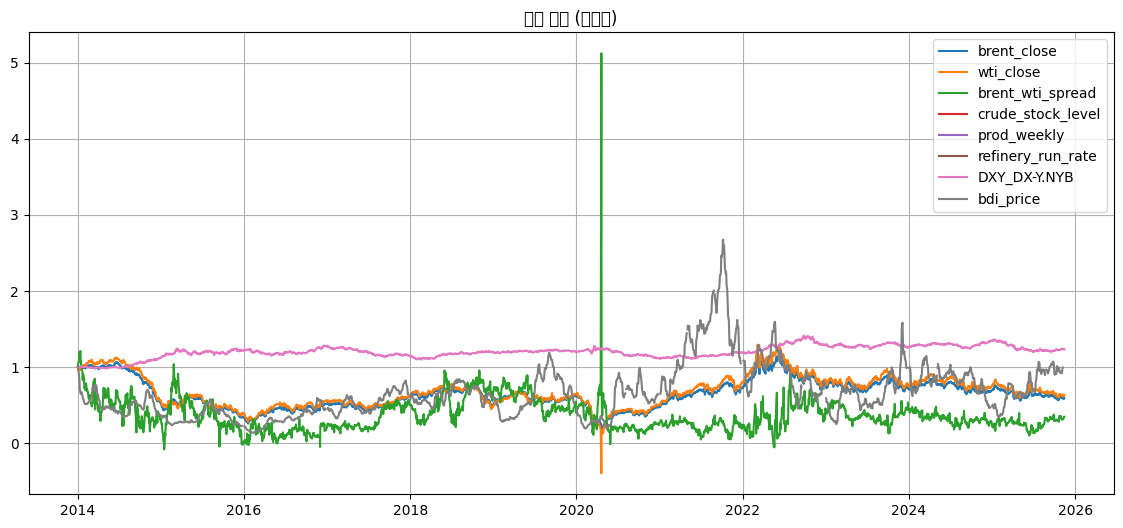

In [15]:
#핵심 시계열 라인 플롯

cols_to_plot = [
    "brent_close","wti_close","brent_wti_spread",
    "crude_stock_level","prod_weekly","refinery_run_rate",
    "DXY_DX-Y.NYB","us2y_yield_x","us10y_yield_x","bdi_price"
]
cols_to_plot = [c for c in cols_to_plot if c in df.columns]

plt.figure(figsize=(14,6))
for c in cols_to_plot:
    s = df[c]
    s = s / s.iloc[0]  # 정규화
    plt.plot(df["Date"], s, label=c)
plt.legend(); plt.title("핵심 지표 (정규화)"); plt.grid(True); plt.show()


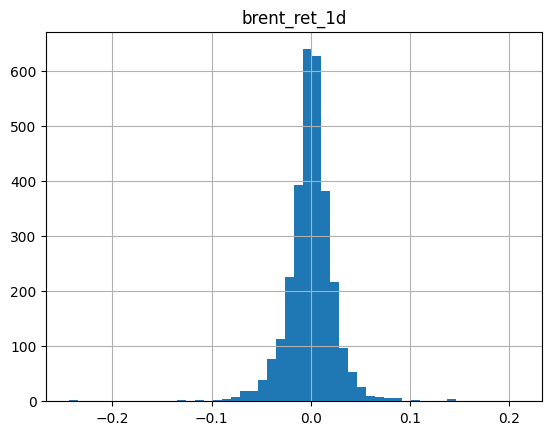

brent_ret_1d 상하위 1%: {0.01: -0.06553646685607543, 0.99: 0.06382170280993531}


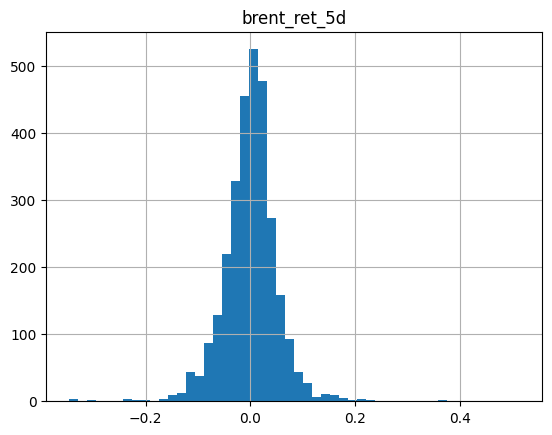

brent_ret_5d 상하위 1%: {0.01: -0.13503244973380124, 0.99: 0.1516591902661385}


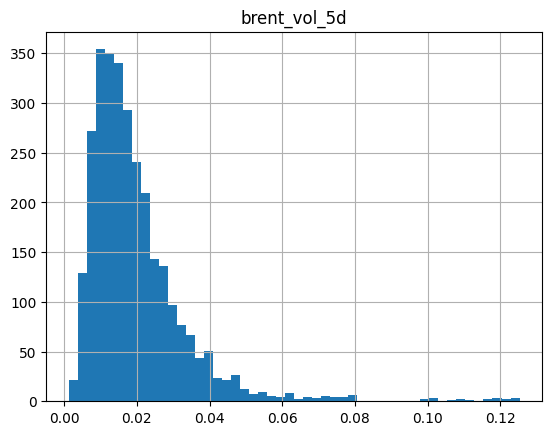

brent_vol_5d 상하위 1%: {0.01: 0.004003811612381608, 0.99: 0.07454406028356679}


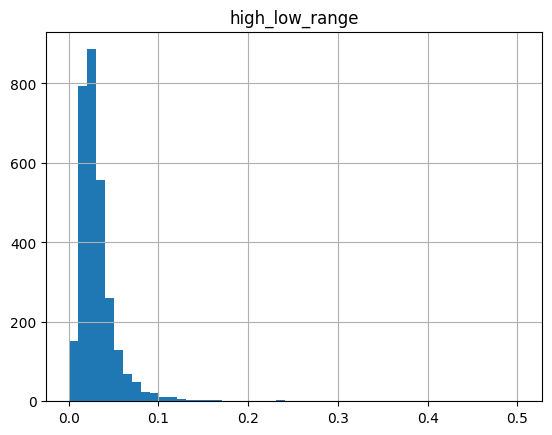

high_low_range 상하위 1%: {0.01: 0.0, 0.99: 0.11253767330014987}


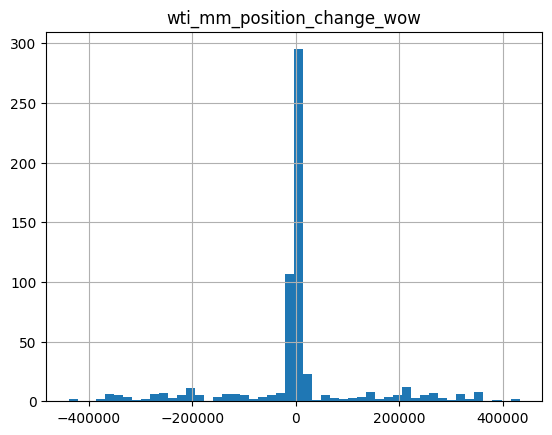

wti_mm_position_change_wow 상하위 1%: {0.01: -363582.0, 0.99: 348762.86}


In [16]:
for c in ["brent_ret_1d","brent_ret_5d","brent_vol_5d","high_low_range","wti_mm_position_change_wow"]:
    if c in df.columns:
        df[c].hist(bins=50); plt.title(c); plt.show()
        print(c, "상하위 1%:", df[c].quantile([0.01,0.99]).to_dict())


# 이벤트 관점에서

In [17]:
 # 변동성 급등일 표시


# 일간 수익률(로그/단순 중 하나) 확정
if "brent_ret_1d" in df.columns:
    ret = df["brent_ret_1d"]
else:
    ret = np.log(df["brent_close"]).diff()

thr = ret.abs().quantile(0.98)  # 상위 2% 절대변동
df["event_large_move"] = (ret.abs() >= thr).astype(int)
df[["Date","brent_close","event_large_move"]].tail(10)


,Date,brent_close,event_large_move
2975,2025-11-03,64.889999,0
2976,2025-11-04,64.440002,0
2977,2025-11-05,63.520000,0
2978,2025-11-06,63.380001,0
2979,2025-11-07,63.630001,0
2980,2025-11-10,64.059998,0
2981,2025-11-11,65.160004,0
2982,2025-11-12,62.709999,0
2983,2025-11-13,63.009998,0
2984,2025-11-14,64.389999,0


In [18]:
df['event_large_move'].value_counts()

event_large_move
0    2925
1      60
Name: count, dtype: int64

In [19]:
# 4-2. 재고/포지션 급변일 표시

def spike_flag(s, q=0.98):
    th = s.abs().quantile(q)
    return (s.abs() >= th).astype(int)

flag_cols = []
for c in ["crude_stock_wow_change","prod_wow_change","wti_mm_position_change_wow"]:
    if c in df.columns:
        df[f"flag_{c}"] = spike_flag(df[c])
        flag_cols.append(f"flag_{c}")

df[["Date"] + flag_cols].tail(10)


,Date,flag_crude_stock_wow_change,flag_prod_wow_change,flag_wti_mm_position_change_wow
2975,2025-11-03,0,0,0
2976,2025-11-04,0,0,0
2977,2025-11-05,0,0,0
2978,2025-11-06,0,0,0
2979,2025-11-07,0,0,0
2980,2025-11-10,0,0,0
2981,2025-11-11,0,0,0
2982,2025-11-12,0,0,0
2983,2025-11-13,0,0,0
2984,2025-11-14,0,0,0


In [20]:
for c in ['flag_crude_stock_wow_change','flag_prod_wow_change','flag_wti_mm_position_change_wow']:
    print(df[c].value_counts().head())
    print("-" * 40)


flag_crude_stock_wow_change
0    2922
1      63
Name: count, dtype: int64
----------------------------------------
flag_prod_wow_change
0    2922
1      63
Name: count, dtype: int64
----------------------------------------
flag_wti_mm_position_change_wow
0    2972
1      13
Name: count, dtype: int64
----------------------------------------


In [21]:
print("event_large_move = 1 개수:", df["event_large_move"].sum())
for c in flag_cols:
    print(c, "= 1 개수:", df[c].sum())

# 교집합 개수 확인
for c in flag_cols:
    inter = ((df["event_large_move"] == 1) & (df[c] == 1)).sum()
    print(f"event_large_move & {c} 둘 다 1인 날:", inter)


event_large_move = 1 개수: 60
flag_crude_stock_wow_change = 1 개수: 63
flag_prod_wow_change = 1 개수: 63
flag_wti_mm_position_change_wow = 1 개수: 13
event_large_move & flag_crude_stock_wow_change 둘 다 1인 날: 7
event_large_move & flag_prod_wow_change 둘 다 1인 날: 1
event_large_move & flag_wti_mm_position_change_wow 둘 다 1인 날: 0


###  유가 급등락 38일
- 6일은 원유 재고 스파이크랑 겹침
- 1일은 생산 스파이크랑 겹치고
- 그냥 0인거는 지연효과나 분위기 지표이지 않을까


=== flag_crude_stock_wow_change ===
                                 mean       std  count
flag_crude_stock_wow_change                           
0                            0.000160  0.023029   2922
1                           -0.002004  0.054470     63

=== flag_prod_wow_change ===
                          mean       std  count
flag_prod_wow_change                           
0                     0.000068  0.024187   2922
1                     0.002233  0.019780     63

=== flag_wti_mm_position_change_wow ===
                                     mean       std  count
flag_wti_mm_position_change_wow                           
0                                0.000079  0.024128   2972
1                                0.008183  0.015523     13


c:\Users\SKAX\Desktop\project\Market-Plan-B-AI\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50630 (\N{HANGUL SYLLABLE EOBS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\SKAX\Desktop\project\Market-Plan-B-AI\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51020 (\N{HANGUL SYLLABLE EUM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\SKAX\Desktop\project\Market-Plan-B-AI\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\SKAX\Desktop\project\Market-Plan-B-AI\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54028 (\N{HANGUL SYLLABLE PA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\SKAX\Desktop\project\Market-Plan-B-AI\venv\Lib\site-packages\IPython\core\p

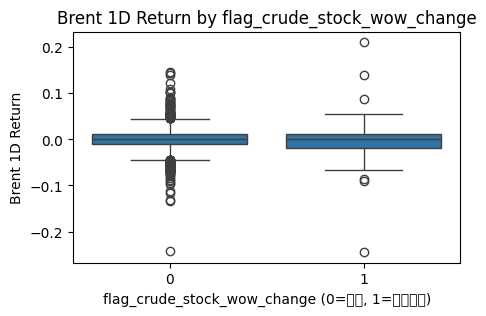

c:\Users\SKAX\Desktop\project\Market-Plan-B-AI\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50630 (\N{HANGUL SYLLABLE EOBS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\SKAX\Desktop\project\Market-Plan-B-AI\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51020 (\N{HANGUL SYLLABLE EUM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\SKAX\Desktop\project\Market-Plan-B-AI\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\SKAX\Desktop\project\Market-Plan-B-AI\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54028 (\N{HANGUL SYLLABLE PA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\SKAX\Desktop\project\Market-Plan-B-AI\venv\Lib\site-packages\IPython\core\p

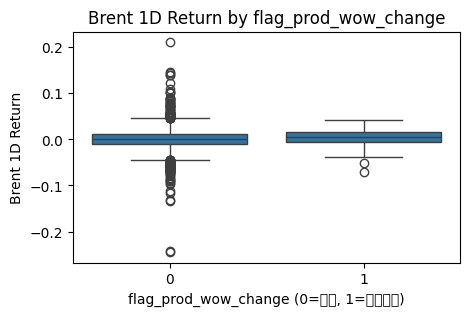

c:\Users\SKAX\Desktop\project\Market-Plan-B-AI\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50630 (\N{HANGUL SYLLABLE EOBS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\SKAX\Desktop\project\Market-Plan-B-AI\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51020 (\N{HANGUL SYLLABLE EUM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\SKAX\Desktop\project\Market-Plan-B-AI\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\SKAX\Desktop\project\Market-Plan-B-AI\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54028 (\N{HANGUL SYLLABLE PA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\SKAX\Desktop\project\Market-Plan-B-AI\venv\Lib\site-packages\IPython\core\p

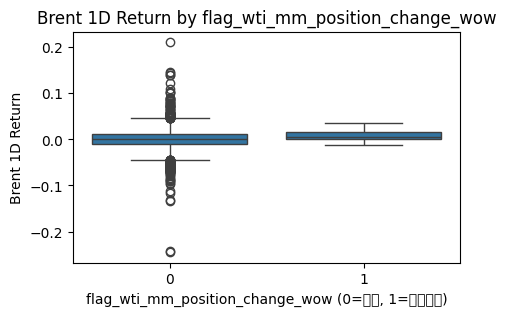


flag_crude_stock_wow_change - event_large_move 비율
event_large_move                    0         1
flag_crude_stock_wow_change                    
0                            0.981862  0.018138
1                            0.888889  0.111111

flag_prod_wow_change - event_large_move 비율
event_large_move             0         1
flag_prod_wow_change                    
0                     0.979808  0.020192
1                     0.984127  0.015873

flag_wti_mm_position_change_wow - event_large_move 비율
event_large_move                        0         1
flag_wti_mm_position_change_wow                    
0                                0.979812  0.020188
1                                1.000000  0.000000


In [22]:
# 비교 대상
targets = ["crude_stock_wow_change", "prod_wow_change", "wti_mm_position_change_wow"]
flag_cols = [f"flag_{c}" for c in targets]

# 1️⃣ 스파이크 발생 여부별 평균 수익률 비교
for flag in flag_cols:
    print(f"\n=== {flag} ===")
    grp = df.groupby(flag)["brent_ret_1d"].agg(["mean","std","count"])
    print(grp)

# 2️⃣ 시각화: 박스플롯 (스파이크 vs 비스파이크 구간의 유가 수익률 분포)
for flag in flag_cols:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=df[flag], y=df["brent_ret_1d"])
    plt.title(f"Brent 1D Return by {flag}")
    plt.xlabel(f"{flag} (0=없음, 1=스파이크)")
    plt.ylabel("Brent 1D Return")
    plt.show()

# 3️⃣ 유가 급등락(event_large_move) 발생률 비교
for flag in flag_cols:
    p_table = pd.crosstab(df[flag], df["event_large_move"], normalize='index')
    print(f"\n{flag} - event_large_move 비율")
    print(p_table)


flag_crude_stock_wow_change : 얘는 1에서 수익률 더 낮고 급등락 비율이 9배? 가까이 높음 > 재고 발표가 시장 변동성 트리거 가능성

생산변화는 영향 미미하고

포지션 급변은 비동시적이다. 심리 반영이 며칠 지나고 하는거 같애요

### 상관관계 보기

In [23]:
# 브렌트 1일 수익률이 이미 있으면 사용, 없으면 즉석 생성
if "brent_ret_1d" in df.columns:
    y = df["brent_ret_1d"]
else:
    y = np.log(df["brent_close"]).diff()

cand = [
    # 수급
    "crude_stock_wow_change","crude_stock_vs_5yr_avg",
    "gas_stock_wow_change","dist_stock_wow_change",
    "prod_wow_change","prod_weekly","refinery_run_rate",
    # 심리/포지션
    "wti_mm_net_long","wti_mm_net_long_ratio","wti_producer_hedge_ratio",
    "wti_mm_position_change_wow","wti_sentiment_position",
    # 거시/위험
    "DXY_DX-Y.NYB","us2y_yield_x","us10y_yield_x","term_spread_x",
    # 가격/기술
    "brent_wti_spread","brent_vol_5d","high_low_range",
    # 기타
    "bdi_price"
]
cand = [c for c in cand if c in df.columns]

corr_now = {}
for c in cand:
    corr_now[c] = pd.Series(y).corr(df[c])
pd.Series(corr_now).sort_values(ascending=False)


wti_mm_net_long_ratio         0.060222
wti_mm_net_long               0.055803
bdi_price                     0.018714
crude_stock_vs_5yr_avg        0.016298
wti_sentiment_position        0.009078
brent_vol_5d                  0.004099
dist_stock_wow_change        -0.002455
gas_stock_wow_change         -0.002455
wti_mm_position_change_wow   -0.003923
DXY_DX-Y.NYB                 -0.007554
prod_weekly                  -0.011254
wti_producer_hedge_ratio     -0.011504
prod_wow_change              -0.022702
crude_stock_wow_change       -0.026375
brent_wti_spread             -0.039150
refinery_run_rate            -0.042972
high_low_range               -0.143577
dtype: float64

In [24]:
def lag_corr(x, y, max_lag=10):
    out = {}
    for k in range(0, max_lag+1):
        out[k] = pd.Series(y).corr(pd.Series(x).shift(k))
    return pd.Series(out)

max_lag = 10
lag_table = {}
for c in cand:
    lag_table[c] = lag_corr(df[c], y, max_lag=max_lag)

lag_df = pd.DataFrame(lag_table)  # index=lag(k일 뒤), column=변수
display(lag_df)


,crude_stock_wow_change,crude_stock_vs_5yr_avg,gas_stock_wow_change,dist_stock_wow_change,prod_wow_change,prod_weekly,refinery_run_rate,wti_mm_net_long,wti_mm_net_long_ratio,wti_producer_hedge_ratio,wti_mm_position_change_wow,wti_sentiment_position,DXY_DX-Y.NYB,brent_wti_spread,brent_vol_5d,high_low_range,bdi_price
0,-0.026375,0.016298,-0.002455,-0.002455,-0.022702,-0.011254,-0.042972,0.055803,0.060222,-0.011504,-0.003923,0.009078,-0.007554,-0.039150,0.004099,-0.143577,0.018714
1,-0.029790,0.014851,0.006255,0.006255,-0.012900,-0.010657,-0.043165,-0.018653,-0.013609,-0.003829,-0.021874,0.031176,-0.005132,-0.119544,0.026189,0.054491,0.013182
2,-0.008028,0.017174,0.007688,0.007688,0.006350,-0.009656,-0.049105,-0.026547,-0.025878,0.032859,-0.029284,-0.011862,-0.006741,-0.021390,0.007868,0.028370,0.010699
3,-0.002053,0.020285,-0.011072,-0.011072,0.013254,-0.009487,-0.056250,0.013847,0.011381,0.035486,-0.015527,0.026820,-0.008776,-0.018232,-0.007308,0.013729,0.009729
4,0.020800,0.020370,0.000421,0.000421,0.020241,-0.008908,-0.052451,-0.005507,-0.022635,0.060575,-0.022350,-0.054752,-0.007185,-0.033367,0.018630,-0.015002,0.013349
5,0.013187,0.019110,0.000653,0.000653,0.020908,-0.008220,-0.046753,0.037993,0.029324,-0.004060,-0.012594,0.001194,-0.004476,-0.056310,0.027887,0.020247,0.012646
6,0.014978,0.017729,-0.001056,-0.001056,0.015413,-0.008215,-0.045694,0.015040,0.001503,-0.025303,0.034876,0.025488,-0.004056,-0.024489,0.050753,0.051551,0.010305
7,0.009727,0.018239,-0.011288,-0.011288,0.013582,-0.009527,-0.052269,0.003058,-0.014858,0.002266,0.016185,-0.008646,-0.003890,0.000220,0.039202,0.034832,0.015281
8,0.011608,0.018812,-0.003825,-0.003825,0.010973,-0.009019,-0.053120,0.033199,0.022143,0.007696,-0.026818,0.056210,-0.003847,0.013664,0.033760,0.061021,0.015182
9,0.011291,0.017641,-0.003951,-0.003951,-0.005626,-0.009601,-0.047336,0.027056,0.012457,0.024515,0.013876,-0.012353,-0.002539,-0.000174,0.031330,0.048613,0.012790


의미 있어 보이는 애들 모음

| 범주           | 핵심 변수                                               | 유의한 시차 | 해석 요약                          |
| ------------ | --------------------------------------------------- | ------ | ------------------------------ |
| **수급(단기)**   | `brent_wti_spread`, `refinery_run_rate`             | 0~1일   | 지역 수급·공급 가동률 변화가 다음날 유가에 반영    |
| **심리(지연형)**  | `wti_producer_hedge_ratio`, `wti_mm_net_long_ratio` | 3~5일   | 선물 포지션·헤지 활동의 심리 변화가 며칠 후 반영   |
| **변동성(중기)**  | `brent_vol_5d`, `high_low_range`                    | 0~7일   | 단기 조정 후 추세 재개 (vol clustering) |
| **실물수요(장기)** | `bdi_price`                                         | 7~10일  | 실물 운송 수요가 서서히 유가에 반영           |


In [25]:
from scipy.stats import pearsonr

for c in cand:
    r, p = pearsonr(df[c].dropna(), y.loc[df[c].dropna().index])
    print(f"{c:30s} r={r:.3f}, p={p:.3e}")

crude_stock_wow_change         r=-0.026, p=1.498e-01
crude_stock_vs_5yr_avg         r=0.016, p=3.735e-01
gas_stock_wow_change           r=-0.002, p=8.934e-01
dist_stock_wow_change          r=-0.002, p=8.934e-01
prod_wow_change                r=-0.023, p=2.151e-01
prod_weekly                    r=-0.011, p=5.389e-01
refinery_run_rate              r=-0.043, p=1.890e-02
wti_mm_net_long                r=0.056, p=1.687e-01
wti_mm_net_long_ratio          r=0.060, p=1.374e-01
wti_producer_hedge_ratio       r=-0.012, p=7.768e-01
wti_mm_position_change_wow     r=-0.004, p=9.230e-01
wti_sentiment_position         r=0.009, p=8.229e-01
DXY_DX-Y.NYB                   r=-0.008, p=6.800e-01
brent_wti_spread               r=-0.039, p=3.245e-02
brent_vol_5d                   r=0.004, p=8.229e-01
high_low_range                 r=-0.144, p=3.224e-15
bdi_price                      r=0.019, p=3.147e-01


| 변수군                  | 유의성                                          | 해석 요약               |
| -------------------- | -------------------------------------------- | ------------------- |
| **강함 (p<0.05)**      | `high_low_range`, `refinery_run_rate`        | 시장 내부 신호 (가격/공급 관련) |
| **약하지만 합리적 (p~0.1)** | `crude_stock_wow_change`, `brent_wti_spread` | 단기 수급 변화 반영         |
| **lag형 유효**          | `wti_producer_hedge_ratio`, `bdi_price` 등    | 주간 단위 심리·실물 반영      |
| **무의미**              | 거시금리, 달러지수 등                                 | 단기 유가에는 거의 영향 없음    |


(11, 17)
   crude_stock_wow_change  crude_stock_vs_5yr_avg  gas_stock_wow_change  \
0               -0.026375                0.016298             -0.002455   
1               -0.029790                0.014851              0.006255   
2               -0.008028                0.017174              0.007688   
3               -0.002053                0.020285             -0.011072   
4                0.020800                0.020370              0.000421   

   dist_stock_wow_change  prod_wow_change  prod_weekly  refinery_run_rate  \
0              -0.002455        -0.022702    -0.011254          -0.042972   
1               0.006255        -0.012900    -0.010657          -0.043165   
2               0.007688         0.006350    -0.009656          -0.049105   
3              -0.011072         0.013254    -0.009487          -0.056250   
4               0.000421         0.020241    -0.008908          -0.052451   

   wti_mm_net_long  wti_mm_net_long_ratio  wti_producer_hedge_ratio  \
0     

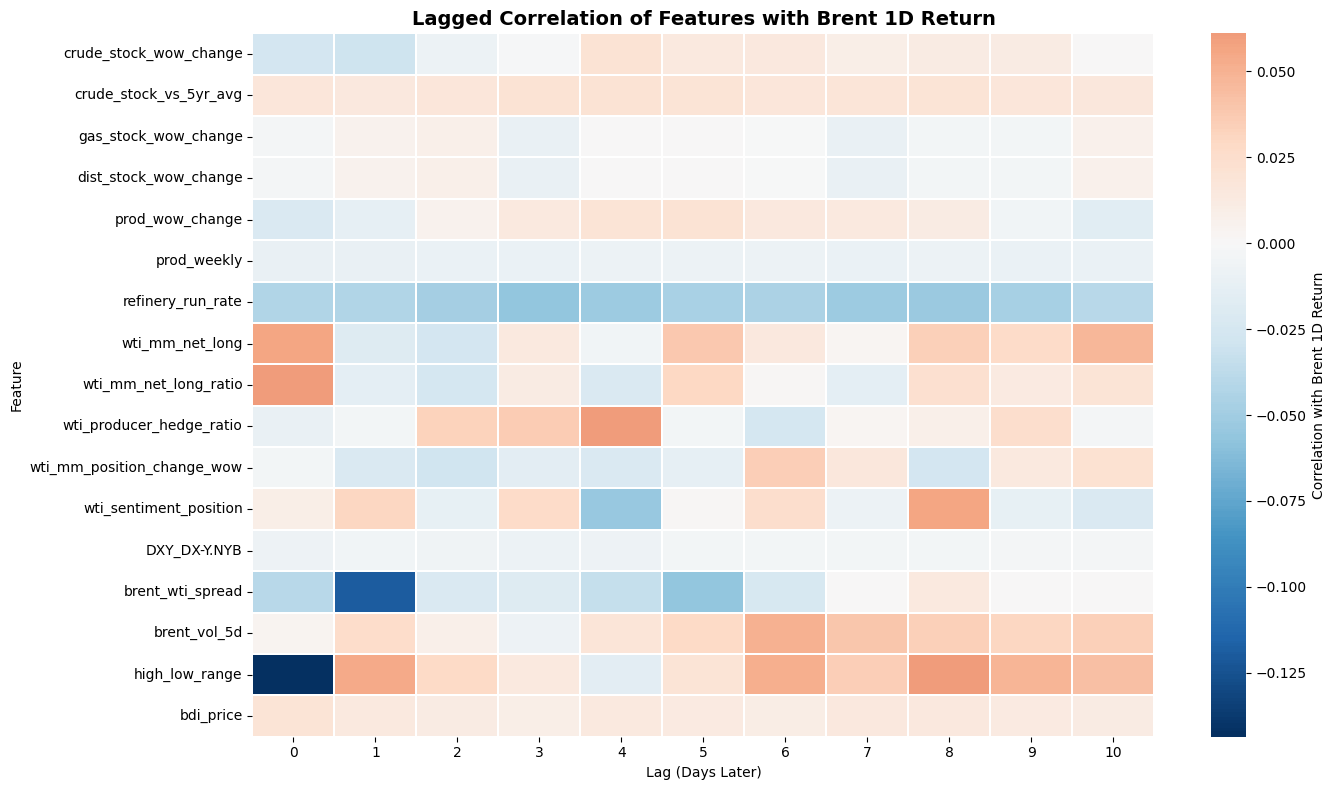

In [26]:
# 1️⃣ lag_df 확인 (index=lag일, columns=변수)
print(lag_df.shape)
print(lag_df.head())

# 2️⃣ 시각화 스타일 세팅
plt.figure(figsize=(14, 8))
sns.heatmap(
    lag_df.T,  # 변수들이 y축, lag이 x축
    cmap="RdBu_r",  # 빨강(양) ↔ 파랑(음)
    center=0,
    annot=False,
    linewidths=0.3,
    cbar_kws={"label": "Correlation with Brent 1D Return"},
)

plt.title("Lagged Correlation of Features with Brent 1D Return", fontsize=14, fontweight="bold")
plt.xlabel("Lag (Days Later)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


생산자가 헷지 많이 하는데 오히려 유가가 상승한다 > 역심리라고 보냐
- 생산자: 유가 충분히 올랐다 > 헷지 : short 포지션 증가
- 투기자: 반대로 long 유지 / 확대 : 포지션 편향 심화
- 며칠 지나고: 둘이 충돌 > 숏커버링 > 유가 반등

| 피처                         | 상관(lag 0) | lag 3~5           | 해석                 |
| -------------------------- | --------- | ----------------- | ------------------ |
| `wti_producer_hedge_ratio` | +0.05     | **+0.09 ~ +0.11** | 역심리형, 후행 상승        |
| `wti_mm_net_long`          | +0.05     | 0 → -0.05         | 투기적 포지션은 단기 과열로 조정 |
| `refinery_run_rate`        | -0.05     | 계속 음              | 공급 신호는 즉시 반영       |
| `bdi_price`                | +0.02     | +0.06             | 실물 수요는 천천히 반영      |


결론: wti_producer_hedge_ratio를 그대로 쓰지말고 shock_decay로 쓰자 (행동 기반 신호가 오래 가니까)
| 항목           | 단순값 (`wti_producer_hedge_ratio`) | shock_decay                      |
| ------------ | -------------------------------- | -------------------------------- |
| **발표 주기**    | 주 1회 → 일간 예측엔 시차 문제              | 발표일 기준으로 decay 적용                |
| **정보 누수 위험** | 지난주 값이 ffill로 남음                 | 발표일에만 유효하게 반영                    |
| **시장 반응 속도** | 즉시 반응 가정 (비현실적)                  | 점진적 반영 (half-life 구조)            |
| **모델 학습 효과** | 노이즈 많음                           | smoother, 더 잘 학습됨                |
| **해석 가능성**   | 해석 어려움                           | “이번 주 충격이 X일 동안 남아있다”로 직관적 설명 가능 |



In [27]:
df["wti_producer_hedge_ratio_lag3"] = df["wti_producer_hedge_ratio"].shift(3)
df["wti_producer_hedge_ratio_lag5"] = df["wti_producer_hedge_ratio"].shift(5)

In [28]:
df.to_csv('checkpoint_1111.csv',index=False)

In [29]:
df=pd.read_csv('checkpoint_1111.csv')
df.head()

,Date,brent_close,wti_close,brent_wti_spread,brent_ret_1d,brent_ret_5d,brent_ret_20d,brent_ma_5,brent_ma_20,brent_ma_60,brent_vol_5d,high_low_range,crude_stock_level,gas_stock_level,dist_stock_level,crude_stock_wow_change,gas_stock_wow_change,dist_stock_wow_change,crude_stock_vs_5yr_avg,gas_stock_vs_5yr_avg,dist_stock_vs_5yr_avg,prod_weekly,prod_4w_ma,prod_wow_change,crude_exports,crude_imports,import_4w_ma,net_imports,refinery_run_rate,wti_mm_net_long,wti_mm_net_long_ratio,wti_producer_hedge_ratio,wti_mm_position_change_wow,wti_sentiment_position,DXY_DX-Y.NYB,XLE_XLE,VDE_VDE,IXC_IXC,"('DXY', 'DX-Y.NYB')_ret_1d","('XLE', 'XLE')_ret_1d","('VDE', 'VDE')_ret_1d","('IXC', 'IXC')_ret_1d",us10y_yield,us2y_yield,term_spread,bdi_price,bdi_open,bdi_high,bdi_low,bdi_change_%,wti_mm_net_long_is_update,wti_mm_net_long_shock_raw,wti_mm_net_long_days_since_update,wti_mm_net_long_avail,wti_mm_net_long_shock_decay,wti_mm_net_long_ratio_is_update,wti_mm_net_long_ratio_shock_raw,wti_mm_net_long_ratio_days_since_update,wti_mm_net_long_ratio_avail,wti_mm_net_long_ratio_shock_decay,wti_producer_hedge_ratio_is_update,wti_producer_hedge_ratio_shock_raw,wti_producer_hedge_ratio_days_since_update,wti_producer_hedge_ratio_avail,wti_producer_hedge_ratio_shock_decay,wti_mm_position_change_wow_is_update,wti_mm_position_change_wow_shock_raw,wti_mm_position_change_wow_days_since_update,wti_mm_position_change_wow_avail,wti_mm_position_change_wow_shock_decay,wti_sentiment_position_is_update,wti_sentiment_position_shock_raw,wti_sentiment_position_days_since_update,wti_sentiment_position_avail,wti_sentiment_position_shock_decay,event_large_move,flag_crude_stock_wow_change,flag_prod_wow_change,flag_wti_mm_position_change_wow,wti_producer_hedge_ratio_lag3,wti_producer_hedge_ratio_lag5
0,2014-01-02,107.779999,95.440002,12.339996,-0.027256,-0.036819,-0.032930,110.790001,110.6705,109.391334,0.011831,0.033680,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,80.629997,55.728355,85.919937,27.177940,NaN,NaN,NaN,NaN,3.00,0.39,2.61,2113.0,2113.0,2113.0,2113.0,-0.0720,0,NaN,NaN,0,NaN,0,NaN,NaN,0,NaN,0,NaN,NaN,0,NaN,0,NaN,NaN,0,NaN,0,NaN,NaN,0,NaN,0,0,0,0,NaN,NaN
1,2014-01-03,106.889999,93.959999,12.930000,-0.008258,-0.045455,-0.050879,109.772000,110.3840,109.356167,0.010935,0.017214,326737.0,226959.0,226959.0,-3958.0,6243.0,6243.0,-0.025439,0.048841,0.048841,8145.0,8108.75,0.002955,58.0,7961.0,7680.75,7903.0,92.3,NaN,NaN,NaN,NaN,NaN,80.790001,55.523968,85.713120,27.133375,0.001984,-0.003668,-0.002407,-0.001640,3.01,0.41,2.60,2036.0,2036.0,2036.0,2036.0,-0.0364,0,NaN,NaN,0,NaN,0,NaN,NaN,0,NaN,0,NaN,NaN,0,NaN,0,NaN,NaN,0,NaN,0,NaN,NaN,0,NaN,0,0,0,0,NaN,NaN
2,2014-01-06,106.730003,93.430000,13.300003,-0.001497,-0.048583,-0.046031,108.682001,110.1265,109.310667,0.010182,0.012836,326737.0,226959.0,226959.0,-3958.0,6243.0,6243.0,-0.025439,0.048841,0.048841,8145.0,8108.75,0.002955,58.0,7961.0,7680.75,7903.0,92.3,NaN,NaN,NaN,NaN,NaN,80.650002,55.600628,85.692451,27.031513,-0.001733,0.001381,-0.000241,-0.003754,2.98,0.40,2.58,1951.0,1951.0,1951.0,1951.0,-0.0417,0,NaN,NaN,0,NaN,0,NaN,NaN,0,NaN,0,NaN,NaN,0,NaN,0,NaN,NaN,0,NaN,0,NaN,NaN,0,NaN,0,0,0,0,NaN,NaN
3,2014-01-07,107.349998,93.669998,13.680000,0.005809,-0.034709,-0.032709,107.910001,109.9450,109.271834,0.012422,0.007452,326737.0,226959.0,226959.0,-3958.0,6243.0,6243.0,-0.025439,0.048841,0.048841,8145.0,8108.75,0.002955,58.0,7961.0,7680.75,7903.0,92.3,50512.0,0.09363,0.252797,-5451.0,1.0,80.830002,56.022179,86.361214,27.241602,0.002232,0.007582,0.007804,0.007772,2.96,0.40,2.56,1876.0,1876.0,1876.0,1876.0,-0.0384,1,NaN,0.0,0,NaN,1,NaN,0.0,0,NaN,1,NaN,0.0,0,NaN,1,NaN,0.0,0,NaN,1,NaN,0.0,0,NaN,0,0,0,0,NaN,NaN
4,2014-01-08,107.150002,92.330002,14.820000,-0.001863,-0.032942,-0.039961,107.180000,109.7220,109.221667,0.012569,0.008493,326737.0,226959.0,226959.0,-3958.0,6243.0,6243.0,-0.025439,0.048841,0.048841,8145.0,8108.75,0.002955,58.0,7961.0,7680.75,7903.0,92.3,NaN,NaN,NaN,NaN,NaN,81.040001,55

## 스프레드 고/저 구간

스프레드 자체는 미국 vs 글로벌 시장 상대적 긴장도를 요약한거고, 다른 변수랑 거의 중복 안된다고 함.

그래서 새로운 정보량이라치고, 파생변수를 만든다면

1. 구간화: 비선형 효과 잡기. 쓰레드홀드 ㅇㅣ펙트를 선형 모델이 더 잘 캐치하면 좋겠음
- 회귀랑 트리에서도 R^2 개선 효과 잇다고들 하는데
2. 해석용으로 유의하다: shap가 양인지 음인지 바로 보여서?

In [30]:
if "brent_wti_spread" in df.columns:
    q_low, q_high = df["brent_wti_spread"].quantile([0.2, 0.8])
    df["spread_regime"] = np.where(df["brent_wti_spread"] <= q_low, "Low",
                            np.where(df["brent_wti_spread"] >= q_high, "High", "Mid"))
    print(df["spread_regime"].value_counts())
    
    # 각 구간에서의 하루 수익률 분포
    if "brent_ret_1d" in df.columns:
        print(df.groupby("spread_regime")["brent_ret_1d"].describe())


spread_regime
Mid     1791
High     597
Low      597
Name: count, dtype: int64
                count      mean       std       min       25%       50%  \
spread_regime                                                             
High            597.0 -0.000715  0.024098 -0.244036 -0.009292  0.000000   
Low             597.0  0.000178  0.024734 -0.131583 -0.011448  0.000180   
Mid            1791.0  0.000369  0.023896 -0.240998 -0.010847  0.001134   

                    75%       max  
spread_regime                      
High           0.009066  0.138603  
Low            0.013356  0.100171  
Mid            0.012472  0.210186  


In [31]:
#  정성 구간 인코딩 낮 걍 높
df["spread_regime_code"] = df["spread_regime"].map({"Low": -1, "Mid": 0, "High": 1})

# 극단 구간도 플래그: 유가 평형상태 깨진날들
df["spread_extreme"] = (df["spread_regime"] != "Mid").astype(int)

# 스프레드 변화율 기반 시그널: 갑자기 차이 벌어질수록 리스크프리미엄이 가격에 반영될수도
df["spread_chg_5d"] = df["brent_wti_spread"].diff(5)


## 재고 편차(5년 평균 대비) 구간

이건 걍 상식적으로 나옴
- crude_stock_vs_5yr_avg: (현재원유재고-과거 5년평균)/5년평균
    - 값이 높을수록 > 공급여유 > 유가 하방 압력
    - 값이 낮을수록 > 공급타이트 > 유가 상방 압력

In [32]:
if "crude_stock_vs_5yr_avg" in df.columns:
    q1, q3 = df["crude_stock_vs_5yr_avg"].quantile([0.25, 0.75])
    df["crude_vs5_regime"] = pd.cut(df["crude_stock_vs_5yr_avg"], 
                                    bins=[-np.inf, q1, q3, np.inf],
                                    labels=["Tight(낮음)","Normal","Loose(높음)"])
    if "brent_ret_1d" in df.columns:
        print(df.groupby("crude_vs5_regime")["brent_ret_1d"].describe())


                   count      mean       std       min       25%       50%  \
crude_vs5_regime                                                             
Tight(낮음)          746.0  0.000063  0.023774 -0.131583 -0.011939  0.001011   
Normal            1495.0 -0.000376  0.021703 -0.240998 -0.009505  0.000627   
Loose(높음)          743.0  0.001188  0.028592 -0.244036 -0.012610  0.000213   

                       75%       max  
crude_vs5_regime                      
Tight(낮음)         0.013070  0.146131  
Normal            0.009961  0.210186  
Loose(높음)         0.015003  0.138603  


C:\Users\SKAX\AppData\Local\Temp\ipykernel_29508\2471015725.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby("crude_vs5_regime")["brent_ret_1d"].describe())


In [33]:
df["crude_vs5_regime_code"] = df["crude_vs5_regime"].map({
    "Tight(낮음)": -1, "Normal": 0, "Loose(높음)": 1
})
df["crude_vs5_extreme"] = (df["crude_vs5_regime"] != "Normal").astype(int)
df["crude_vs5_zscore"] = (df["crude_stock_vs_5yr_avg"] - 
                          df["crude_stock_vs_5yr_avg"].mean()) / df["crude_stock_vs_5yr_avg"].std()


In [34]:
df.columns

Index(['Date', 'brent_close', 'wti_close', 'brent_wti_spread', 'brent_ret_1d',
       'brent_ret_5d', 'brent_ret_20d', 'brent_ma_5', 'brent_ma_20',
       'brent_ma_60', 'brent_vol_5d', 'high_low_range', 'crude_stock_level',
       'gas_stock_level', 'dist_stock_level', 'crude_stock_wow_change',
       'gas_stock_wow_change', 'dist_stock_wow_change',
       'crude_stock_vs_5yr_avg', 'gas_stock_vs_5yr_avg',
       'dist_stock_vs_5yr_avg', 'prod_weekly', 'prod_4w_ma', 'prod_wow_change',
       'crude_exports', 'crude_imports', 'import_4w_ma', 'net_imports',
       'refinery_run_rate', 'wti_mm_net_long', 'wti_mm_net_long_ratio',
       'wti_producer_hedge_ratio', 'wti_mm_position_change_wow',
       'wti_sentiment_position', 'DXY_DX-Y.NYB', 'XLE_XLE', 'VDE_VDE',
       'IXC_IXC', '('DXY', 'DX-Y.NYB')_ret_1d', '('XLE', 'XLE')_ret_1d',
       '('VDE', 'VDE')_ret_1d', '('IXC', 'IXC')_ret_1d', 'us10y_yield',
       'us2y_yield', 'term_spread', 'bdi_price', 'bdi_open', 'bdi_high',
       'bdi_

# 마지막으로 다중공선성 확인

난중에 모델링할때, refinery_run_rate는 버리고 crude_stock_vs_5yr_avg ↔ crude_vs5_regime_code 둘 중 하나만 쓰기 (아마 코드)

In [35]:
def compute_vif(df, features):
    """
    df: 원본 DataFrame
    features: VIF 계산할 컬럼 리스트
    """
    X = df[features].copy()

    # 결측치 있으면 간단히 드롭 (필요 시 더 정교한 처리 가능)
    X = X.replace([np.inf, -np.inf], np.nan).dropna()

    vif_data = []
    for i, col in enumerate(X.columns):
        vif = variance_inflation_factor(X.values, i)
        vif_data.append({"feature": col, "VIF": vif})

    return pd.DataFrame(vif_data).sort_values("VIF", ascending=False)


In [36]:
# 스프레드 & 재고 구조 변수만

features_v1 = [
    "brent_wti_spread",          # 원 시계열
    "spread_regime_code",        # High/Mid/Low 코드화 (-1,0,1)
    "crude_stock_vs_5yr_avg",    # 구조적 재고
    "crude_vs5_regime_code"      # Tight/Normal/Loose 코드화 (-1,0,1)
]

vif_v1 = compute_vif(df, features_v1)
print(vif_v1)

                  feature       VIF
2  crude_stock_vs_5yr_avg  5.257766
3   crude_vs5_regime_code  4.397874
0        brent_wti_spread  2.004851
1      spread_regime_code  1.594885


In [37]:
features_refined = [
    "brent_wti_spread",
    "spread_regime_code",
    "crude_vs5_regime_code"
]

vif_refined = compute_vif(df, features_refined)
print(vif_refined)


                 feature       VIF
1     spread_regime_code  1.207766
0       brent_wti_spread  1.189240
2  crude_vs5_regime_code  1.018794


In [38]:
def compute_vif(df, features, min_samples=50):
    X = df[features].replace([np.inf, -np.inf], np.nan).dropna()
    print(f"[{len(features)}개 피처 중] 유효 표본 수:", X.shape[0])
    if X.shape[0] == 0:
        print("⚠️ 모든 피처에 결측치가 많아서 계산 불가")
        return pd.DataFrame()
    vif_data = []
    for i, col in enumerate(X.columns):
        try:
            vif = variance_inflation_factor(X.values, i)
        except Exception:
            vif = np.nan
        vif_data.append({"feature": col, "VIF": vif})
    return pd.DataFrame(vif_data).sort_values("VIF", ascending=False)

# 1. 구조 그룹
vif_struct = compute_vif(df, [
    "brent_wti_spread","spread_regime_code",
    "crude_stock_vs_5yr_avg","crude_vs5_regime_code",
    "refinery_run_rate","prod_weekly","prod_wow_change"
])

# 2. 심리 그룹
vif_sentiment = compute_vif(df, [
    "wti_producer_hedge_ratio","wti_producer_hedge_ratio_shock_decay",
    "wti_producer_hedge_ratio_lag3",
    "wti_mm_net_long","wti_mm_net_long_ratio",
    "wti_mm_position_change_wow","wti_sentiment_position"
])

# 3. 기술 그룹
vif_market = compute_vif(df, [
    "brent_vol_5d","high_low_range","spread_chg_5d",
    "bdi_price","DXY_DX-Y.NYB","term_spread_x",
    "us2y_yield_x","us10y_yield_x"
])



[7개 피처 중] 유효 표본 수: 2984
[7개 피처 중] 유효 표본 수: 0
⚠️ 모든 피처에 결측치가 많아서 계산 불가


KeyError: "['term_spread_x', 'us2y_yield_x', 'us10y_yield_x'] not in index"

In [ ]:
features_refined = [
    # 구조
    "spread_regime_code", "crude_vs5_regime_code",
    "refinery_run_rate", "prod_wow_change",

    # 심리
    "wti_producer_hedge_ratio_shock_decay",
    "wti_mm_net_long_ratio_shock_decay",

    # 기술/시장
    "brent_vol_5d", "term_spread_x", "bdi_price"
]

vif_refined = compute_vif(df, features_refined)
print(vif_refined)


[9개 피처 중] 유효 표본 수: 1787
                                feature        VIF
2                     refinery_run_rate  12.636564
8                             bdi_price   7.038331
7                         term_spread_x   3.609755
5     wti_mm_net_long_ratio_shock_decay   3.363714
4  wti_producer_hedge_ratio_shock_decay   3.358518
6                          brent_vol_5d   2.709790
1                 crude_vs5_regime_code   1.487080
0                    spread_regime_code   1.204162
3                       prod_wow_change   1.014925


In [ ]:
# refinery_run_rate 제거 후 다시 확인
reduced = [
    "bdi_price","term_spread_x","wti_mm_net_long_ratio_shock_decay",
    "wti_producer_hedge_ratio_shock_decay","brent_vol_5d",
    "crude_vs5_regime_code","spread_regime_code","prod_wow_change"
]
vif_reduced = compute_vif(df, reduced)
print(vif_reduced)


[8개 피처 중] 유효 표본 수: 1787
                                feature       VIF
2     wti_mm_net_long_ratio_shock_decay  3.361653
3  wti_producer_hedge_ratio_shock_decay  3.358226
0                             bdi_price  3.183832
1                         term_spread_x  2.593483
4                          brent_vol_5d  2.016336
5                 crude_vs5_regime_code  1.453274
6                    spread_regime_code  1.190667
7                       prod_wow_change  1.014598


In [ ]:
df.to_csv('checkpoint_1112.csv',index=False)

In [ ]:
df.tail()

,Date,brent_close,wti_close,brent_wti_spread,brent_ret_1d,brent_ret_5d,brent_ret_20d,brent_ma_5,brent_ma_20,brent_ma_60,brent_vol_5d,high_low_range,crude_stock_level,gas_stock_level,dist_stock_level,crude_stock_wow_change,gas_stock_wow_change,dist_stock_wow_change,crude_stock_vs_5yr_avg,gas_stock_vs_5yr_avg,dist_stock_vs_5yr_avg,prod_weekly,prod_4w_ma,prod_wow_change,crude_exports,crude_imports,import_4w_ma,net_imports,refinery_run_rate,wti_mm_net_long,wti_mm_net_long_ratio,wti_producer_hedge_ratio,wti_mm_position_change_wow,wti_sentiment_position,DXY_DX-Y.NYB,XLE_XLE,VDE_VDE,IXC_IXC,"('DXY', 'DX-Y.NYB')_ret_1d","('XLE', 'XLE')_ret_1d","('VDE', 'VDE')_ret_1d","('IXC', 'IXC')_ret_1d",us10y_yield_x,us2y_yield_x,term_spread_x,us10y_yield_y,us2y_yield_y,term_spread_y,bdi_price,bdi_open,bdi_high,bdi_low,bdi_change_%,wti_mm_net_long_is_update,wti_mm_net_long_shock_raw,wti_mm_net_long_days_since_update,wti_mm_net_long_avail,wti_mm_net_long_shock_decay,wti_mm_net_long_ratio_is_update,wti_mm_net_long_ratio_shock_raw,wti_mm_net_long_ratio_days_since_update,wti_mm_net_long_ratio_avail,wti_mm_net_long_ratio_shock_decay,wti_producer_hedge_ratio_is_update,wti_producer_hedge_ratio_shock_raw,wti_producer_hedge_ratio_days_since_update,wti_producer_hedge_ratio_avail,wti_producer_hedge_ratio_shock_decay,wti_mm_position_change_wow_is_update,wti_mm_position_change_wow_shock_raw,wti_mm_position_change_wow_days_since_update,wti_mm_position_change_wow_avail,wti_mm_position_change_wow_shock_decay,wti_sentiment_position_is_update,wti_sentiment_position_shock_raw,wti_sentiment_position_days_since_update,wti_sentiment_position_avail,wti_sentiment_position_shock_decay,event_large_move,flag_crude_stock_wow_change,flag_prod_wow_change,flag_wti_mm_position_change_wow,wti_producer_hedge_ratio_lag3,wti_producer_hedge_ratio_lag5,spread_regime,crude_vs5_regime,spread_regime_code,spread_extreme,spread_chg_5d,crude_vs5_regime_code,crude_vs5_extreme,crude_vs5_zscore
1862,2021-06-02,71.349998,68.830002,2.519997,0.015658,0.039330,0.035859,69.912000,68.5165,66.583667,0.005323,0.015697,479270.0,233980.0,233980.0,-5079.0,1499.0,1499.0,0.024531,-0.013379,-0.013379,10800.0,10950.0,-0.018182,2544.0,5631.0,5950.75,3087.0,88.7,NaN,NaN,NaN,NaN,NaN,89.900002,46.598904,65.604759,22.918268,0.000779,0.018628,0.019398,0.018148,1.59,0.13,1.46,1.59,0.13,1.46,2530.0,2530.0,2530.0,2530.0,-0.000148,0,NaN,1.0,1,15693.046800,0,NaN,1.0,1,0.002810,0,NaN,1.0,1,0.003843,0,NaN,1.0,1,6613.112782,0,NaN,1.0,1,0.0,0,0,0,0,NaN,0.269824,Mid,Normal,0,0,-0.060005,0,0,-0.685651
1863,2021-06-03,71.309998,68.809998,2.500000,-0.000561,0.035429,0.034078,70.399998,68.6340,66.646833,0.006304,0.018511,479270.0,233980.0,233980.0,-5079.0,1499.0,1499.0,0.024531,-0.013379,-0.013379,10800.0,10950.0,-0.018182,2544.0,5631.0,5950.75,3087.0,88.7,NaN,NaN,NaN,NaN,NaN,90.500000,46.725464,65.800102,22.926605,0.006674,0.002716,0.002978,0.000364,1.63,0.16,1.47,1.63,0.16,1.47,2472.0,2472.0,2472.0,2472.0,-0.000229,0,NaN,2.0,1,12455.579499,0,NaN,2.0,1,0.002230,0,NaN,2.0,1,0.003050,0,NaN,2.0,1,5248.831094,0,NaN,2.0,1,0.0,0,0,0,0,NaN,NaN,Mid,Normal,0,0,-0.160004,0,0,-0.685651
1864,2021-06-04,71.889999,69.620003,2.269997,0.008134,0.034984,0.055809,70.885999,68.8240,66.713333,0.006280,0.019613,474029.0,241026.0,241026.0,-5241.0,7046.0,7046.0,0.013551,0.016266,0.016266,11000.0,10950.0,0.018519,2931.0,6638.0,6238.25,3707.0,91.3,NaN,NaN,NaN,NaN,NaN,90.139999,47.037643,66.284180,23.076670,-0.003978,0.006681,0.007357,0.006545,1.56,0.14,1.42,1.56,0.14,1.42,2438.0,2438.0,2438.0,2438.0,-0.000138,0,NaN,3.0,1,9886.000000,0,NaN,3.0,1,0.001770,0,NaN,3.0,1,0.002421,0,NaN,3.0,1,4166.000000,0,NaN,3.0,1,0.0,0,0,0,0,0.274666,NaN,Low,Normal,-1,1,-0.340004,0,0,-0.769909
1865,2021-06-07,71.489998,69.230003,2.259995,-0.005564,0.026713,0.047012,71.257999,68.9845,66.744333,0.008377,0.016226,474029.0,241026.0,241026.0,-5241.0,7046.0,7046.0,0.013551,0.016266,0.016266,11000.0,10950.0,0.018519,2931.0,6638.0,6238.25,3707.0,91.3,NaN,NaN,NaN,NaN,NaN,89.949997

# 진짜 마지막 뉴스임베딩 붙이기

In [ ]:
with open('../data/extra_embedded (2).json', 'r', encoding='utf-8') as f:
    news = json.load(f)

news[-1]

{'title': 'North Dakota Oil Train Conflagration Prompts Increased Federal Scrutiny',
 'url': 'https://oilprice.com/Energy/Crude-Oil/North-Dakota-Oil-Train-Conflagration-Prompts-Increased-Federal-Scrutiny.html',
 'published': 'Jan 02, 2014 at 13:22',
 'category': '국제 유가 동향',
 'content': 'The year 2013 has ended on a worrying note for oil producers in North America’s Bakken region, as a series of recent train incidents in both Canada and the U.S. have highlighted the hazards of moving crude oil by rail.\n\nOn 30 December at 2:12 p.m. a mile-long train of 106 tankers carrying Bakken crude collided with a derailed 112 car westbound grain train carrying soybeans about a mile west of Casselton, a city of 2,432 people about 20 miles west of Fargo. The crash triggered a series of massive explosions sending toxic fumes into the air. Local authorities said that 18 tanker cars caught fire and the Cass County Sheriff\'s Office “strongly” recommended evacuating Casselton and anyone residing five mi

In [ ]:
n = pd.DataFrame(news)

# 각 summary_embedding 길이 측정
n['embedding_length'] = n['summary_embedding'].apply(len)

# 고유한 길이들 확인
print("고유 임베딩 길이들:", n['embedding_length'].unique())

# 길이별 개수 분포
print("\n임베딩 길이별 뉴스 개수:")
print(n['embedding_length'].value_counts())


고유 임베딩 길이들: [64  9]

임베딩 길이별 뉴스 개수:
embedding_length
64    6071
9        9
Name: count, dtype: int64


In [ ]:
n['published'].isnull().sum()

np.int64(9)

In [ ]:
# summary_embedding이 None 또는 NaN인 뉴스만 필터링
bad_embeddings = n[n['summary_embedding'].isnull()]

# 개수 확인
print(f"❗ 임베딩이 None인 뉴스 개수: {len(bad_embeddings)}")

# 예시 출력
print(bad_embeddings[['title', 'published', 'content']].head())


❗ 임베딩이 None인 뉴스 개수: 9
                                                  title  \
2462    Is Shell About To Turn Its Back On The Permian?   
2463  Jet Fuel Demand Poised For A 30% Surge During ...   
2464     Remote Work Is The Newest Trend In Oil And Gas   
3398                    The World’s Most Vulnerable Oil   
3418            Dreams Of An Aramco IPO Are Fading Fast   

                  published                                            content  
2462  Jun 14, 2021 at 08:02  Shell may put up for sale all of its acreage i...  
2463  Jun 11, 2021 at 15:40  The air travel industry is at a critical infle...  
2464  Jun 11, 2021 at 15:32  Remote work was one of the changes bestowed up...  
3398  Nov 13, 2019 at 16:33  A single drone missile can wreak as much havoc...  
3418  Oct 22, 2019 at 10:12  Once again reports are out that Saudi Aramco i...  


---
# 정리

1) 데이터 점검 & 기본 EDA

결측치 커버리지 확인: CFTC 계열은 주간(화요일)만 값 존재 → 데일리 예측에 직접 쓰면 누수/공백 문제.

일간 수익률(brent_ret_1d) 기준 단순 상관/라그 상관 수행 → 단순 상관은 약하지만 시차/레짐에 따라 신호 존재.

2) CFTC(주간) 신호의 데일리화

주간 공개일(화) 기준으로:

*_is_update: 발표일 플래그

*_shock_raw: 이번 주 변화량(전주 대비)

*_days_since_update: 경과일(0=화, 1=수…)

*_shock_decay: 발표 후 반감기 기반 감쇠 캐리(정보 누수 없이 주중에만 효과 확산)

*_avail: 해당 주 신호 유효 구간

해석:

wti_producer_hedge_ratio_shock_decay는 역심리형(contrarian) 특성 → 발표 직후/3~5일 후 가격 반응이 달라짐.

단순 lag보다 shock_decay가 발표 이벤트 구조를 더 잘 encode.

3) 이벤트 플래그 & 스파이크

event_large_move: 유가 절대수익률 상위 2% 급등락일 플래그.

flag_*(재고/생산/포지션 급변일): 상위 2% 스파이크 플래그 생성.

교집합 점검: 큰 변동일과 재고/생산 급변이 겹치는 날은 제한적 → 직접적 원인보다는 조합/레짐 효과가 중요.

4) 레짐(구간) 파생변수

Brent–WTI 스프레드:

분위수 20/80%로 spread_regime(Low/Mid/High) → Mid 구간에서 평균 수익률이 양, 극단(High/Low)에서는 음 → 과열/불균형 시 조정 신호.

spread_regime_code(−1/0/+1), spread_extreme(0/1), spread_chg_5d 생성.

원유 재고의 5년 평균 대비 편차:

crude_stock_vs_5yr_avg를 분위수 25/75%로 crude_vs5_regime(Tight/Normal/Loose).

Normal에서 완만한 양(+) 수익률; Tight/Loose 극단에선 조정 경향 → 구조적 수급 레짐 신호.

코드형(crude_vs5_regime_code)과 z-score도 후보.

5) 통계적 유의 스냅샷

단순 피어슨: 대부분 약함(당연)이나 high_low_range는 음의 상관 유의.

라그 상관: 일부 변수에서 3~5일 레그에 의미 있는 패턴(특히 producer hedge).

6) 다중공선성(VIF) 점검 & 정제

최초 혼합 피처셋에서 refinery_run_rate가 VIF 12.6 → 공급 측 변수와 중복.

정제 후 최종 VIF(8개) 모두 < 4로 안정:

유지 권장:

구조/수급: spread_regime_code, crude_vs5_regime_code, prod_wow_change

심리: wti_producer_hedge_ratio_shock_decay, wti_mm_net_long_ratio_shock_decay

시장/거시: brent_vol_5d, term_spread_x, bdi_price

제거/보류: refinery_run_rate(공선성↑), crude_stock_vs_5yr_avg(레짐 코드와 중복)